### Set Up

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score)

from sklearn.model_selection import train_test_split

import joblib 

### Loading .npz files

In [2]:
class EEGDataLoader:
  """Load .npz files containing EEG signals"""

  def __init__(self, data_dir=os.path.expanduser("~/Desktop/STATS_5243/Subjects_5243")):
        self.data_dir = data_dir

  def load_group(self, patient_list, w):
        """Loads data for a group of patients and returns optionally windowed features, depending on the input w"""
        X_group, y_group = [], []
        for pid in patient_list:
            fpath = os.path.join(self.data_dir, f"{pid}.npz")
            if not os.path.exists(fpath):
                print(f"Warning: {pid} not found. Skipping.")
                continue
            data = np.load(fpath)
            if w > 1:
                X_s, y_s = self._stack_features(data['X'], data['y'], w)
                X_group.append(X_s)
                y_group.append(y_s)
            else:
                X_group.append(data['X'])
                y_group.append(data['y'])

        if not X_group: raise ValueError("No data found!")
        return np.concatenate(X_group, axis=0), np.concatenate(y_group, axis=0)

  def _stack_features(self, X, y, w):
        """Groups several nearby epochs together into one feature block."""
        n_epochs = X.shape[0]
        if n_epochs < w: return np.empty((0, X.shape[1]*w)), np.empty((0,))
        X_new = [X[i : n_epochs - w + 1 + i] for i in range(w)]
        X_new.reverse()
        return np.concatenate(X_new, axis=1), y[w-1:]

### Handling Class Imbalance

In [3]:
def undersample_majority(X, y, target_minority_ratio=0.10):
  """Undersamples the majority class"""
  idx_min = np.where(y == 1)[0]
  idx_maj = np.where(y == 0)[0]
  n_min = len(idx_min)
  
  n_maj_new = int((n_min / target_minority_ratio) - n_min)

  if n_maj_new >= len(idx_maj): return X, y

  np.random.seed(42)
  idx_maj_down = np.random.choice(idx_maj, size=n_maj_new, replace=False)
  idx_combo = np.concatenate([idx_min, idx_maj_down])
  np.random.shuffle(idx_combo)

  return X[idx_combo], y[idx_combo]

### Logistic Regression - Dependent Split

In [4]:
def run_logistic_grid_patient_split(X_train, y_train, X_val, y_val, undersample_configs, C_values):
    """Runs logistic regression (grid search)"""

    results = []
    models = []
    scalers = []

    for ratio in undersample_configs:

        # Undersample
        X_train_u, y_train_u = undersample_majority(
            X_train, y_train, target_minority_ratio=ratio
        )
        print(f"\nUndersample ratio={ratio}: {sum(y_train_u == 1)} pos / {sum(y_train_u == 0)} neg")

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_u)
        X_val_scaled = scaler.transform(X_val)

        for C in C_values:

            model = LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=42)

            # Train
            t0 = time.time()
            model.fit(X_train_scaled, y_train_u)
            train_time = time.time() - t0

            # Predict
            y_pred = model.predict(X_val_scaled)
            y_prob = model.predict_proba(X_val_scaled)[:, 1]

            # Metrics (positive class = seizures)
            precision = precision_score(y_val, y_pred, pos_label=1)
            recall = recall_score(y_val, y_pred, pos_label=1)
            f1 = f1_score(y_val, y_pred, pos_label=1)
            auc = roc_auc_score(y_val, y_prob)
            acc = accuracy_score(y_val, y_pred)

            results.append({
                "undersample_ratio": ratio,
                "C": C,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "AUC": auc,
                "Accuracy": acc,
                "Train Samples": len(y_train_u),
                "Train Time (s)": train_time
            })

            models.append(model)
            scalers.append(scaler)

    df = pd.DataFrame(results)
    return df, models, scalers


In [ ]:
if __name__ == "__main__":
    loader = EEGDataLoader()
    window_size = 3

    # (Original patient lists – now just used to define which patients to include)
    train_pats = [
        'chb16', 'chb10', 'chb01', 'chb09', 'chb19', 'chb13',
        'chb02', 'chb14', 'chb06', 'chb03', 'chb12', 'chb22',
        'chb04', 'chb05', 'chb17a', 'chb17b', 'chb17c'
    ]
    val_pats = ['chb20', 'chb18', 'chb23', 'chb24']
    test_pats = ['chb08', 'chb11', 'chb15', 'chb21', 'chb07']

    # Combine all patients: we will split at the epoch level instead of per-patient
    all_pats = sorted(set(train_pats + val_pats + test_pats))

    print("Loading data…")
    X_all, y_all = loader.load_group(all_pats, window_size)
    print(f"Total samples: {X_all.shape[0]}, seizures={np.sum(y_all)}, non-seizures={np.sum(y_all == 0)}")

    # Epoch-level random split
    print("Performing epoch-level 70/15/15 split (stratified)…")

    # First split: Train (70%) vs Temp (30%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all,
        test_size=0.30,         
        random_state=42,
        shuffle=True,
        stratify=y_all
    )

    # Second split: Validation (15%) vs Test (15%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        random_state=42,
        shuffle=True,
        stratify=y_temp
    )

    print("\nFinal epoch-level split:")
    print(f"Train: {X_train.shape[0]} samples, seizures={np.sum(y_train)}")
    print(f"Val:   {X_val.shape[0]} samples, seizures={np.sum(y_val)}")
    print(f"Test:  {X_test.shape[0]} samples, seizures={np.sum(y_test)}")


    # Hyperparameters to evaluate
    undersample_configs = [0.02, 0.05, 0.10, 0.5]
    C_values = [0.001, 0.01]

    # Run grid search
    results_df, models, scalers = run_logistic_grid_patient_split(
        X_train, y_train,
        X_val, y_val,
        undersample_configs,
        C_values
    )

    print("\nValidation results (sorted by F1):")
    print(results_df.sort_values("F1", ascending=False).to_string(index=False))

    # Select top 3 validation configs
    top3 = results_df.sort_values("F1", ascending=False).head(3)
    print("\nTop 3 configs (validation F1):")
    print(top3[["undersample_ratio", "C", "F1"]].to_string(index=False))

    # Retrain top 3 configs on Train+Val and evaluate on Test
    final_results = []
    final_models = []
    final_scalers = []

    print("\nEvaluating top 3 configs on TEST…")

    for i, row in top3.iterrows():
        ratio = float(row["undersample_ratio"])
        C_val = float(row["C"])

        # Train+Val combined
        X_full = np.vstack([X_train, X_val])
        y_full = np.concatenate([y_train, y_val])

        # Undersample
        X_u, y_u = undersample_majority(X_full, y_full, ratio)

        # Scale
        scaler_f = StandardScaler()
        X_u_scaled = scaler_f.fit_transform(X_u)
        X_test_scaled = scaler_f.transform(X_test)

        # Fit model
        model_f = LogisticRegression(C=C_val, solver="liblinear", max_iter=1000)
        model_f.fit(X_u_scaled, y_u)

        # Predictions
        y_pred = model_f.predict(X_test_scaled)
        y_prob = model_f.predict_proba(X_test_scaled)[:, 1]

        # Metrics
        res = {
            "undersample_ratio": ratio,
            "C": C_val,
            "Test_Accuracy": accuracy_score(y_test, y_pred),
            "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
            "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
            "Test_F1": f1_score(y_test, y_pred, zero_division=0),
            "Test_AUC": roc_auc_score(y_test, y_prob)
        }

        final_results.append(res)
        final_models.append(model_f)
        final_scalers.append(scaler_f)

    # Printing results
    final_df = pd.DataFrame(final_results)
    print("\nTop-3 model performance on TEST:")
    print(final_df.sort_values("Test_F1", ascending=False).to_string(index=False))

    # Best test model
    best_idx = final_df["Test_F1"].idxmax()
    best_row = final_df.loc[best_idx]

    print("\nBest model on TEST:")
    print(best_row)

    # Save best model
    joblib.dump(final_models[best_idx], "best_logreg2_model.pkl")
    joblib.dump(final_scalers[best_idx], "best_logreg2_scaler.pkl")
    print("\nSaved best model and scaler.")

Loading data…
Total samples: 1747068, seizures=5656, non-seizures=1741412
Performing epoch-level 70/15/15 split (stratified)…

Final epoch-level split:
Train: 1222947 samples, seizures=3959
Val:   262060 samples, seizures=848
Test:  262061 samples, seizures=849

Undersample ratio=0.02: 3959 pos / 193991 neg

Undersample ratio=0.05: 3959 pos / 75221 neg

Undersample ratio=0.1: 3959 pos / 35631 neg

Undersample ratio=0.5: 3959 pos / 3959 neg

Validation results (sorted by F1):
 undersample_ratio     C  Precision   Recall       F1      AUC  Accuracy  Train Samples  Train Time (s)
              0.02 0.010   0.284000 0.167453 0.210682 0.778956  0.995940         197950       33.542120
              0.05 0.010   0.171902 0.232311 0.197593 0.815020  0.993895          79180       14.276702
              0.05 0.001   0.189159 0.201651 0.195205 0.800511  0.994620          79180        5.213944
              0.10 0.001   0.146164 0.260613 0.187288 0.804974  0.992681          39590        2.357253


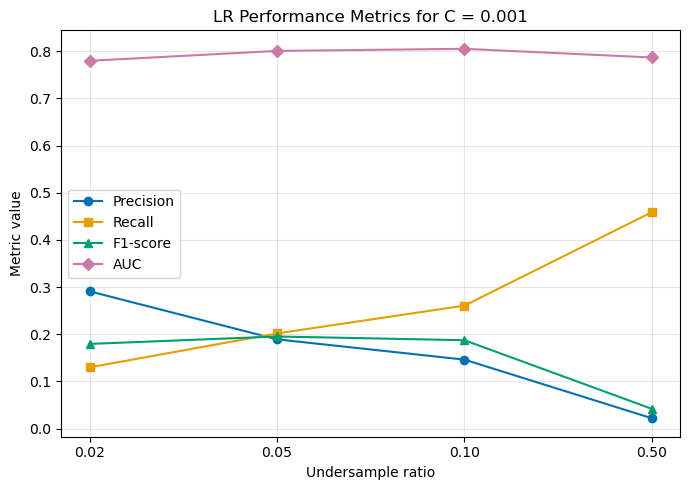

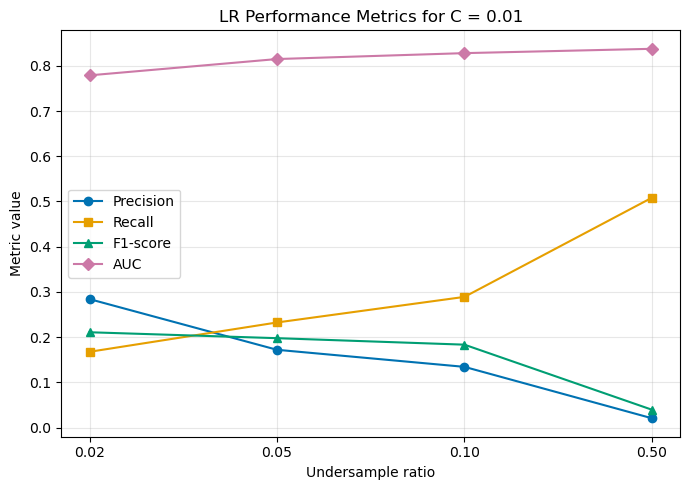

In [ ]:
# Plotting
unique_Cs = sorted(results_df["C"].unique())

# Colorblind friendly colors (Okabe–Ito)
colors = {
    "Precision": "#0072B2",
    "Recall":    "#E69F00",
    "F1":        "#009E73",
    "AUC":       "#CC79A7",
}

for C_val in unique_Cs:

    df_c = results_df[results_df["C"] == C_val].copy()
    df_c = df_c.sort_values("undersample_ratio")

    ratios = df_c["undersample_ratio"].values
    x_idx = np.arange(len(ratios))

    plt.figure(figsize=(7, 5))

    # Plot metrics
    plt.plot(x_idx, df_c["Precision"], marker="o", color=colors["Precision"], label="Precision")
    plt.plot(x_idx, df_c["Recall"],    marker="s", color=colors["Recall"],    label="Recall")
    plt.plot(x_idx, df_c["F1"],        marker="^", color=colors["F1"],        label="F1-score")
    plt.plot(x_idx, df_c["AUC"],       marker="D", color=colors["AUC"],       label="AUC")

  
    plt.xticks(x_idx, [f"{r:.2f}" for r in ratios])
    plt.xlabel("Undersample ratio")
    plt.ylabel("Metric value")
    plt.title(f"LR Performance Metrics for C = {C_val}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()
